1. import thư viện và data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, QuantileTransformer
)
from sklearn.impute import SimpleImputer, KNNImputer


2. EDA_Khám phá dữ liệu

In [2]:
#	Load the dataset
file_path = "E:/AI_du_doan_benh_tim_mach/data/raw_data/heart_disease_uci.csv"
data = pd.read_csv(file_path)
print(data.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [3]:
print(data.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [4]:
#json sang tiếng việt
import json

column_map = {
    'id': 'mã_bệnh_nhân',
    'age': 'tuổi',
    'sex': 'giới_tính',
    'dataset': 'tập_dữ_liệu',
    'cp': 'loại_đau_ngực',
    'trestbps': 'huyết_áp_nghỉ',
    'chol': 'cholesterol',
    'fbs': 'đường_huyết_cao',
    'restecg': 'điện_tâm_đồ',
    'thalch': 'nhịp_tim_tối_đa',
    'exang': 'đau_thắt_ngực',
    'oldpeak': 'ST_chênh_lệch',
    'slope': 'độ_dốc',
    'ca': 'số_mạch_vành',
    'thal': 'thal',
    'num': 'bệnh_tim'
}

with open("E:/AI_du_doan_benh_tim_mach/data/data_process/column_map_tieng_viet.json", "w", encoding="utf-8") as f:
    json.dump(column_map, f, ensure_ascii=False, indent=4)


In [5]:
#in ra số lượng giá trị mỗi cột
print("Số lượng giá trị trong mỗi cột:")
data_counts = data.count()
print(data_counts)

Số lượng giá trị trong mỗi cột:
id          920
age         920
sex         920
dataset     920
cp          920
trestbps    861
chol        890
fbs         830
restecg     918
thalch      865
exang       865
oldpeak     858
slope       611
ca          309
thal        434
num         920
dtype: int64


In [6]:
#phát hiện	giá trị thiếu
missing_values = data.isnull().sum()
print("Giá trị thiếu trong mỗi cột:")
print(missing_values)



Giá trị thiếu trong mỗi cột:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [7]:
#kiểu dữ liệu của mỗi	cột
print("Kiểu dữ liệu của mỗi cột:")
print(data.dtypes)

Kiểu dữ liệu của mỗi cột:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


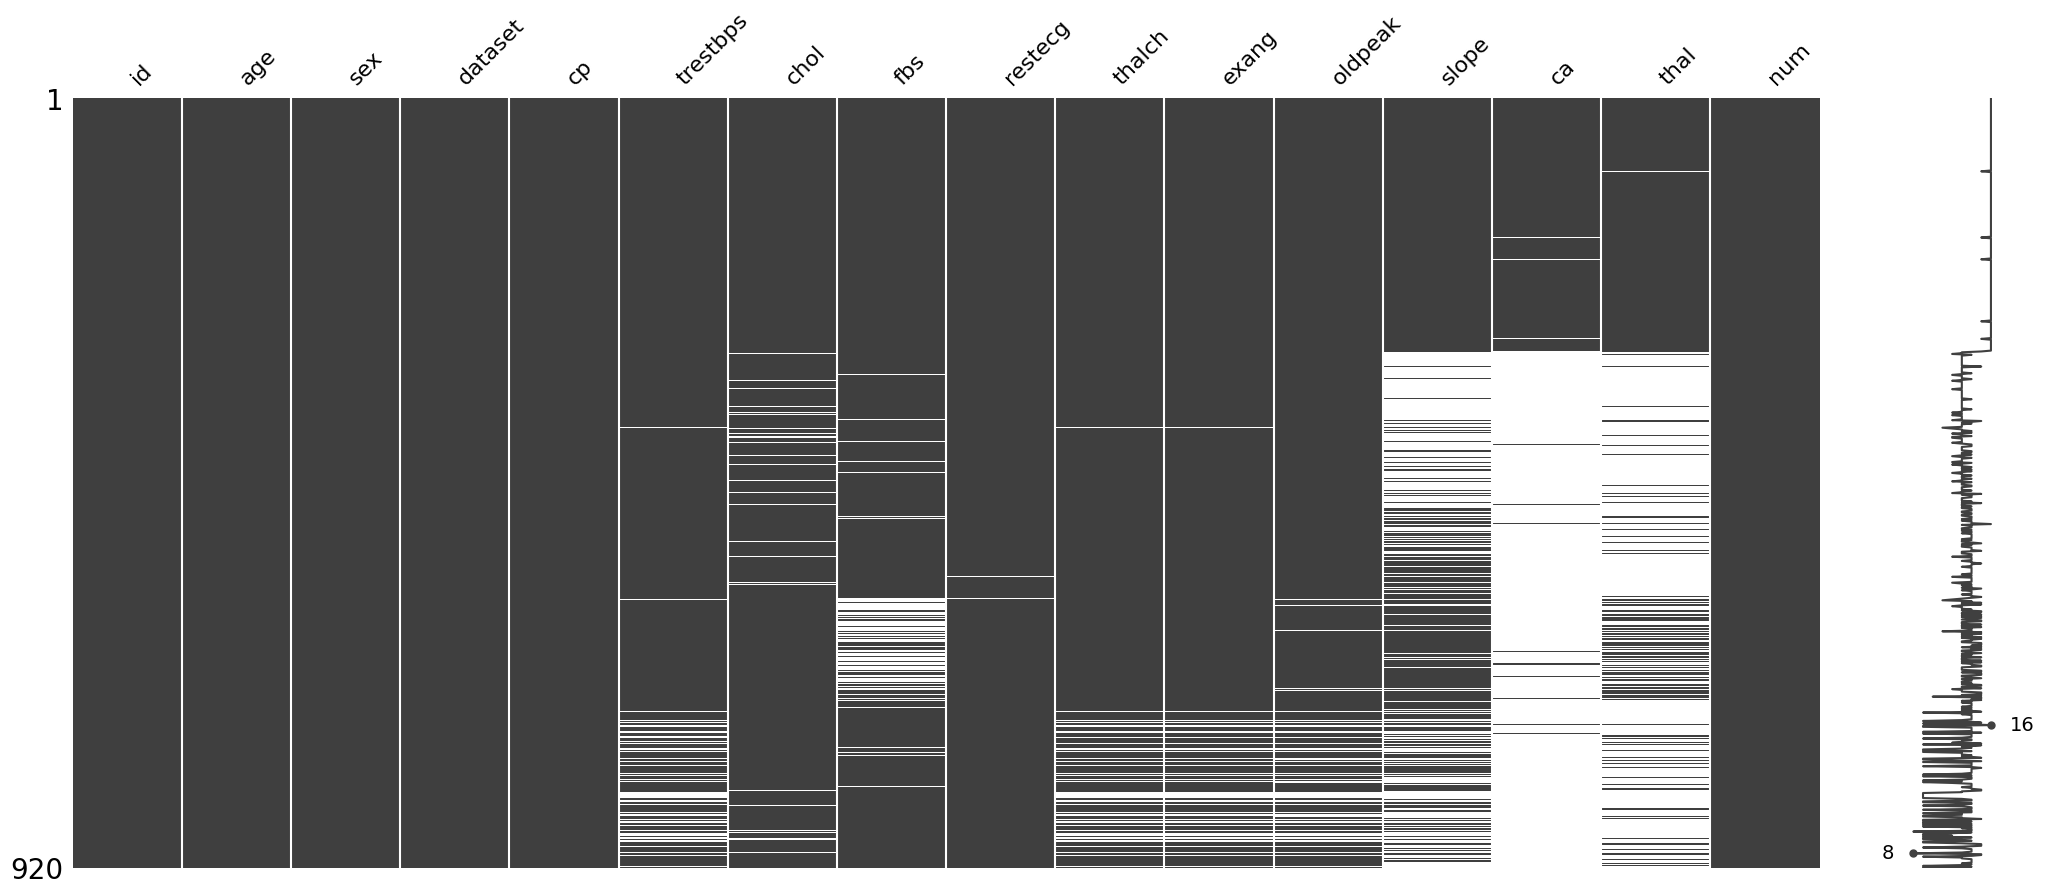

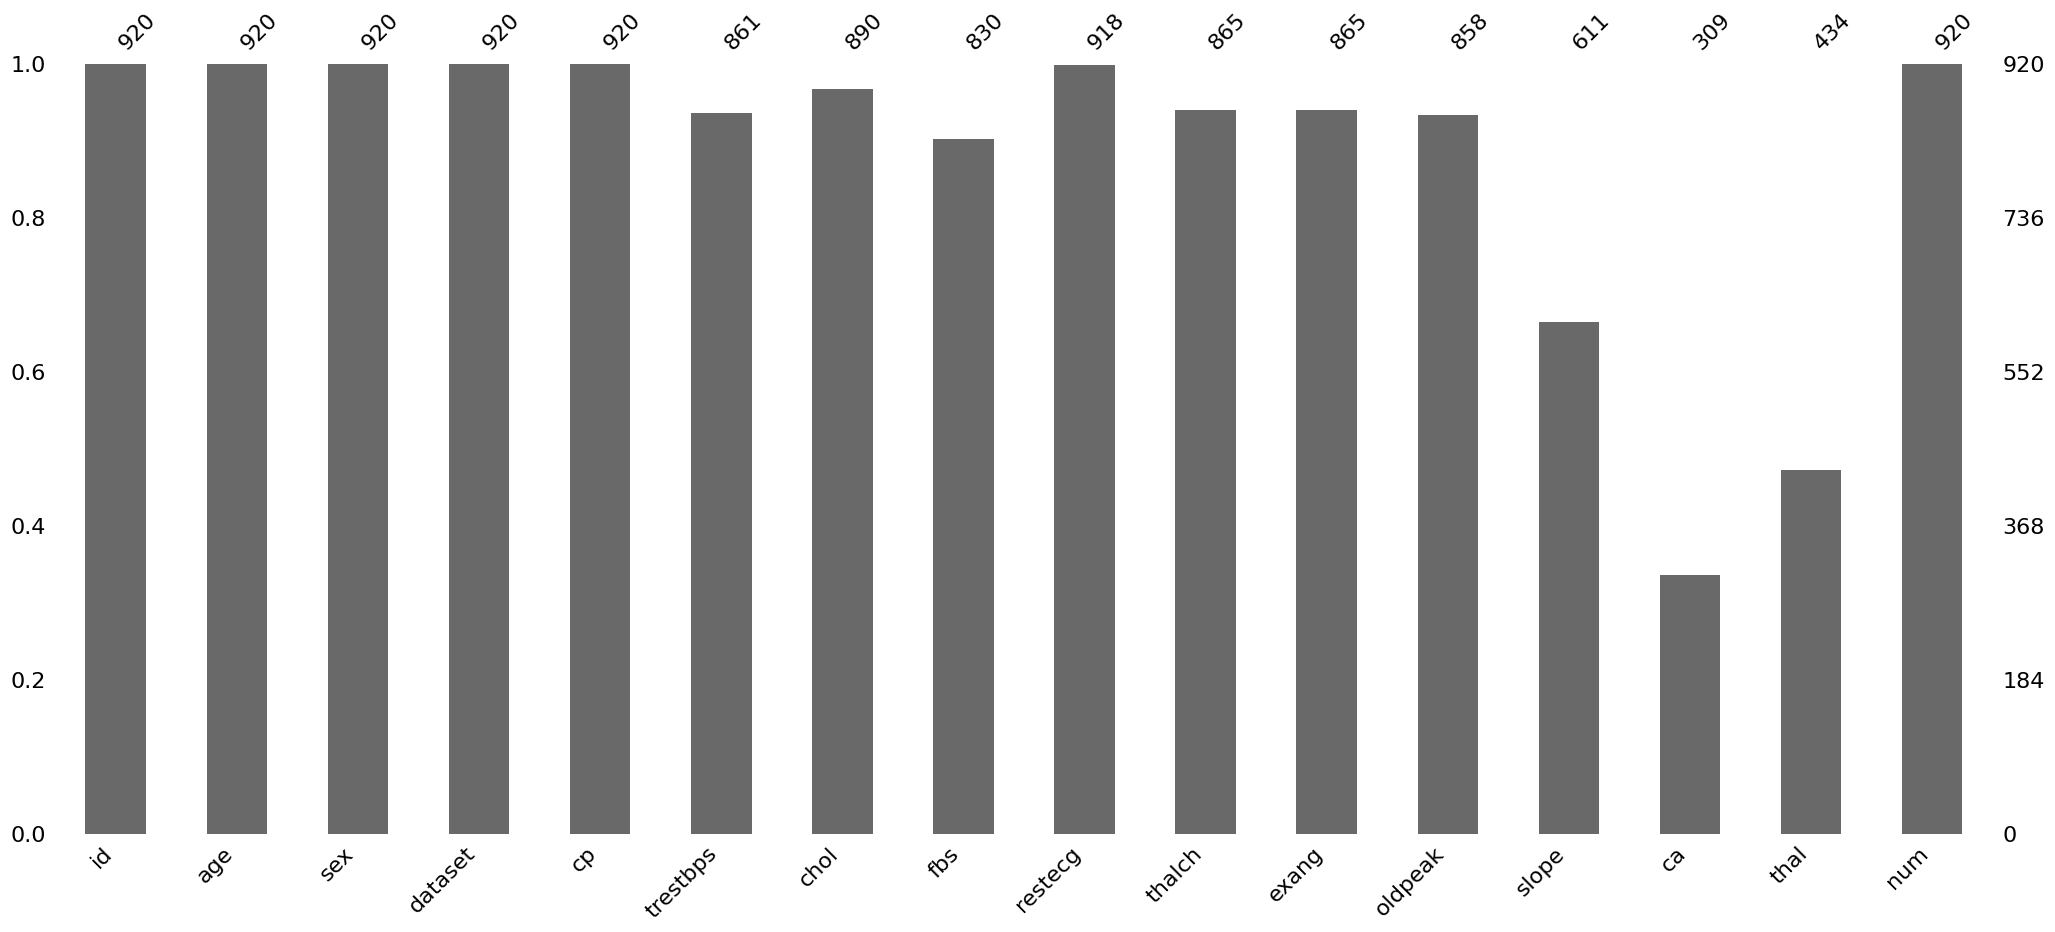

In [8]:
import missingno as msno
# Vẽ ma trận vị trí dữ liệu thiếu
msno.matrix(data) 
plt.show()

# Vẽ biểu đồ thanh tỷ lệ thiếu
msno.bar(data)
plt.show()

3. Xử lý giá trị thiếu

In [9]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer  # phải import trước
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [10]:
# Kiểm tra giá trị gốc trước khi xử lý
columns_low_columns	= ['chol', 'thalch', 'oldpeak']
print("Giá trị gốc trước khi impute:")
print(data[columns_low_columns].head(10))

Giá trị gốc trước khi impute:
    chol  thalch  oldpeak
0  233.0   150.0      2.3
1  286.0   108.0      1.5
2  229.0   129.0      2.6
3  250.0   187.0      3.5
4  204.0   172.0      1.4
5  236.0   178.0      0.8
6  268.0   160.0      3.6
7  354.0   163.0      0.6
8  254.0   147.0      1.4
9  203.0   155.0      3.1


 NHÓM LOW - Xử lý giá trị thiếu (đơn giản)


In [11]:
# 1. Cột số - Dùng MEDIAN
numeric_low_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in numeric_low_cols:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val)
    print(f" Đã điền {col} bằng median = {median_val:.2f}")


 Đã điền trestbps bằng median = 130.00
 Đã điền chol bằng median = 223.00
 Đã điền thalch bằng median = 140.00
 Đã điền oldpeak bằng median = 0.50


In [12]:
# 2. Cột phân loại - Dùng MODE
categorical_low_cols = ['fbs', 'exang', 'restecg']

for col in categorical_low_cols:
    mode_val = data[col].mode()[0]
    data[col] = data[col].fillna(mode_val)
    print(f" Đã điền {col} bằng mode = {mode_val}")

 Đã điền fbs bằng mode = False
 Đã điền exang bằng mode = False
 Đã điền restecg bằng mode = normal


In [13]:
# 3. Kiểm tra kết quả
print(" Kiểm tra missing sau xử lý nhóm LOW:")
print(data[numeric_low_cols + categorical_low_cols].isnull().sum())

 Kiểm tra missing sau xử lý nhóm LOW:
trestbps    0
chol        0
thalch      0
oldpeak     0
fbs         0
exang       0
restecg     0
dtype: int64


In [14]:
#hiển thị	thông tin tổng quan sau khi xử lý
print("Thông tin tổng quan sau khi xử lý:")
print(data.info())
print(data[numeric_low_cols].describe())

Thông tin tổng quan sau khi xử lý:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    object 
 8   restecg   920 non-null    str    
 9   thalch    920 non-null    float64
 10  exang     920 non-null    object 
 11  oldpeak   920 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None
         trestbps        chol      thalch     oldpeak
count  920.000000  920.000000  920.000

Nhóm medium -  IterativeImputer cho slope

In [15]:
# Mã hóa slope
le = LabelEncoder()
slope_not_null = data['slope'].dropna()
le.fit(slope_not_null)
data['slope_encoded'] = pd.Series([np.nan] * len(data), dtype='float64')
data.loc[data['slope'].notna(), 'slope_encoded'] = le.transform(data.loc[data['slope'].notna(), 'slope'])
# Chọn features để impute
features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df_impute = data[features + ['slope_encoded']].copy()

# Iterative Imputer với RandomForest
imp = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42
)
imputed = imp.fit_transform(df_impute)
data['slope_encoded'] = imputed[:, -1].round().astype(int)
data['slope'] = le.inverse_transform(data['slope_encoded'])
data = data.drop(columns=['slope_encoded'])
print("MEDIUM: Đã xử lý slope bằng IterativeImputer")
print("Số lượng missing values trong cột 'slope' sau khi xử lý:", data['slope'].isnull().sum())

MEDIUM: Đã xử lý slope bằng IterativeImputer
Số lượng missing values trong cột 'slope' sau khi xử lý: 0


1. NHÓM HIGH (>50%) - Tạo flag và xóa


In [16]:
# 1. NHÓM HIGH (>50%) - Tạo flag và xóa
ca_missing_count = data['ca'].isnull().sum()
thal_missing_count = data['thal'].isnull().sum()
data['ca_missing'] = data['ca'].isnull().astype(int)
data['thal_missing'] = data['thal'].isnull().astype(int)
data = data.drop(columns=['ca', 'thal'])
print("✅ HIGH: Đã xóa ca, thal và tạo flag missing")
print(f"Số lượng missing values trong cột 'ca' sau khi xử lý: {ca_missing_count}")
print(f"Số lượng missing values trong cột 'thal' sau khi xử lý: {thal_missing_count}")

✅ HIGH: Đã xóa ca, thal và tạo flag missing
Số lượng missing values trong cột 'ca' sau khi xử lý: 611
Số lượng missing values trong cột 'thal' sau khi xử lý: 486


Xử lý giá trị 0 bất thường

In [17]:
# Xử lý giá trị 0 trong trestbps và chol
data.loc[data['trestbps'] == 0, 'trestbps'] = data['trestbps'].median()
data.loc[data['chol'] == 0, 'chol'] = data['chol'].median()

print("✅ Đã xử lý giá trị 0 bất thường")
print(f"trestbps min mới: {data['trestbps'].min()}")
print(f"chol min mới: {data['chol'].min()}")

✅ Đã xử lý giá trị 0 bất thường
trestbps min mới: 80.0
chol min mới: 85.0


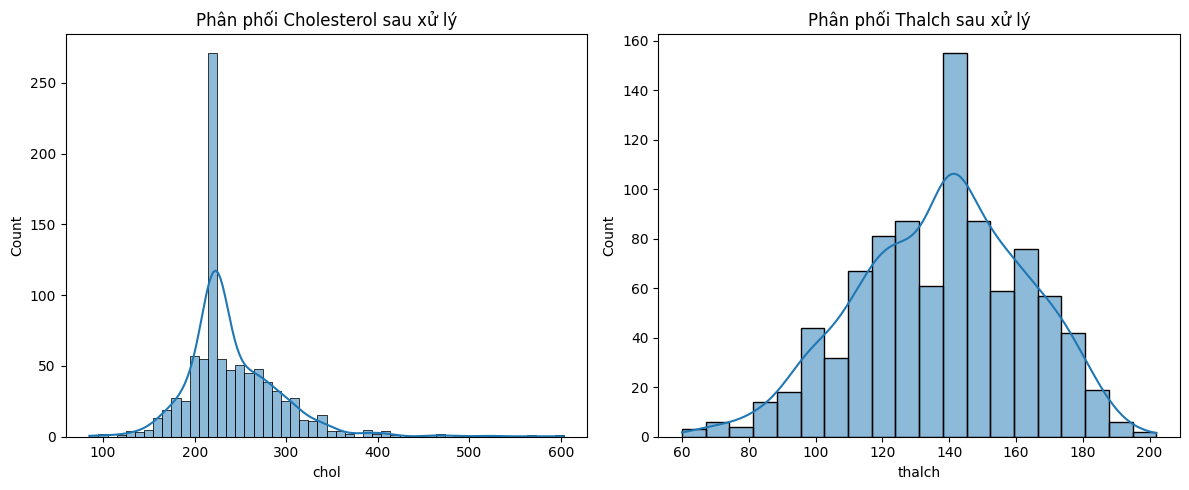

In [18]:
#trực	quan hóa phân phối sau khi xử lý
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['chol'], kde=True)
plt.title('Phân phối Cholesterol sau xử lý')
plt.subplot(1, 2, 2)
sns.histplot(data['thalch'], kde=True)
plt.title('Phân phối Thalch sau xử lý')
plt.tight_layout()
plt.show()


In [19]:
# ============================================
# XỬ LÝ SAU KHI ĐÃ ĐIỀN MISSING
# ============================================

# 1. Xử lý giá trị 0 bất thường
data.loc[data['trestbps'] == 0, 'trestbps'] = data['trestbps'].median()
data.loc[data['chol'] == 0, 'chol'] = data['chol'].median()
print("✅ Đã xử lý giá trị 0 bất thường")

# 2. Mã hóa dữ liệu phân loại
from sklearn.preprocessing import LabelEncoder

# Label Encoding cho cột nhị phân
binary_cols = ['sex', 'fbs', 'exang']
for col in binary_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    print(f"✅ Đã mã hóa {col}")

# One-Hot Encoding cho cột nhiều giá trị
categorical_cols = ['cp', 'restecg', 'slope', 'dataset']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print(f"✅ Đã One-Hot Encoding: {categorical_cols}")

# 3. Chuẩn hóa dữ liệu số
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
print("✅ Đã chuẩn hóa dữ liệu số")

# 4. Xử lý target
data['target'] = (data['num'] > 0).astype(int)
data = data.drop(columns=['num'])
print("✅ Đã chuyển target thành nhị phân")
print(f"\n📊 Phân phối target:\n{data['target'].value_counts()}")

# 5. Kiểm tra lại dữ liệu
print(f"\n📊 Shape sau xử lý: {data.shape}")
print(f"\n📊 Các cột hiện tại:\n{data.columns.tolist()}")

✅ Đã xử lý giá trị 0 bất thường
✅ Đã mã hóa sex
✅ Đã mã hóa fbs
✅ Đã mã hóa exang
✅ Đã One-Hot Encoding: ['cp', 'restecg', 'slope', 'dataset']
✅ Đã chuẩn hóa dữ liệu số
✅ Đã chuyển target thành nhị phân

📊 Phân phối target:
target
1    509
0    411
Name: count, dtype: int64

📊 Shape sau xử lý: (920, 22)

📊 Các cột hiện tại:
['id', 'age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca_missing', 'thal_missing', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach', 'target']


 TRỰC QUAN HÓA TOÀN BỘ DỮ LIỆU SAU XỬ LÝ


In [20]:
# Thiết lập style đẹp
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

1. PHÂN PHỐI TARGET (CÓ BỆNH / KHÔNG BỆNH)


C:\Users\khanh\AppData\Local\Temp\ipykernel_12916\2825440372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=data, ax=axes[1], palette=['#ff9999', '#66b3ff'])


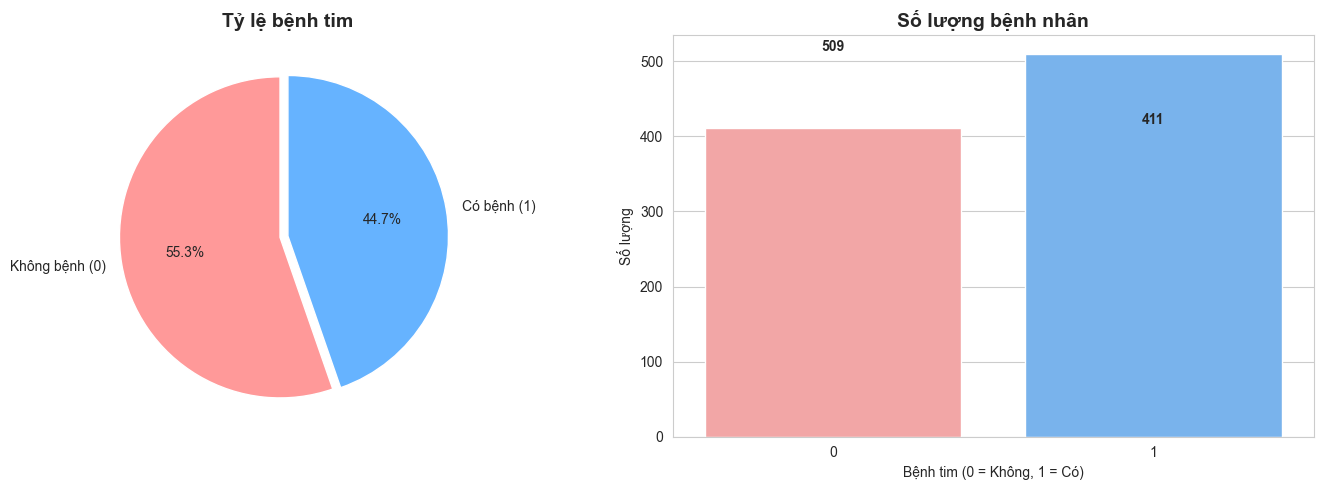

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#ff9999', '#66b3ff']
labels = ['Không bệnh (0)', 'Có bệnh (1)']
sizes = data['target'].value_counts().values
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
axes[0].set_title('Tỷ lệ bệnh tim', fontsize=14, fontweight='bold')

# Count plot
sns.countplot(x='target', data=data, ax=axes[1], palette=['#ff9999', '#66b3ff'])
axes[1].set_title('Số lượng bệnh nhân', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Bệnh tim (0 = Không, 1 = Có)')
axes[1].set_ylabel('Số lượng')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/co_benh_va_khong_benh.png")
plt.show()




2. PHÂN PHỐI CÁC BIẾN SỐ SAU CHUẨN HÓA

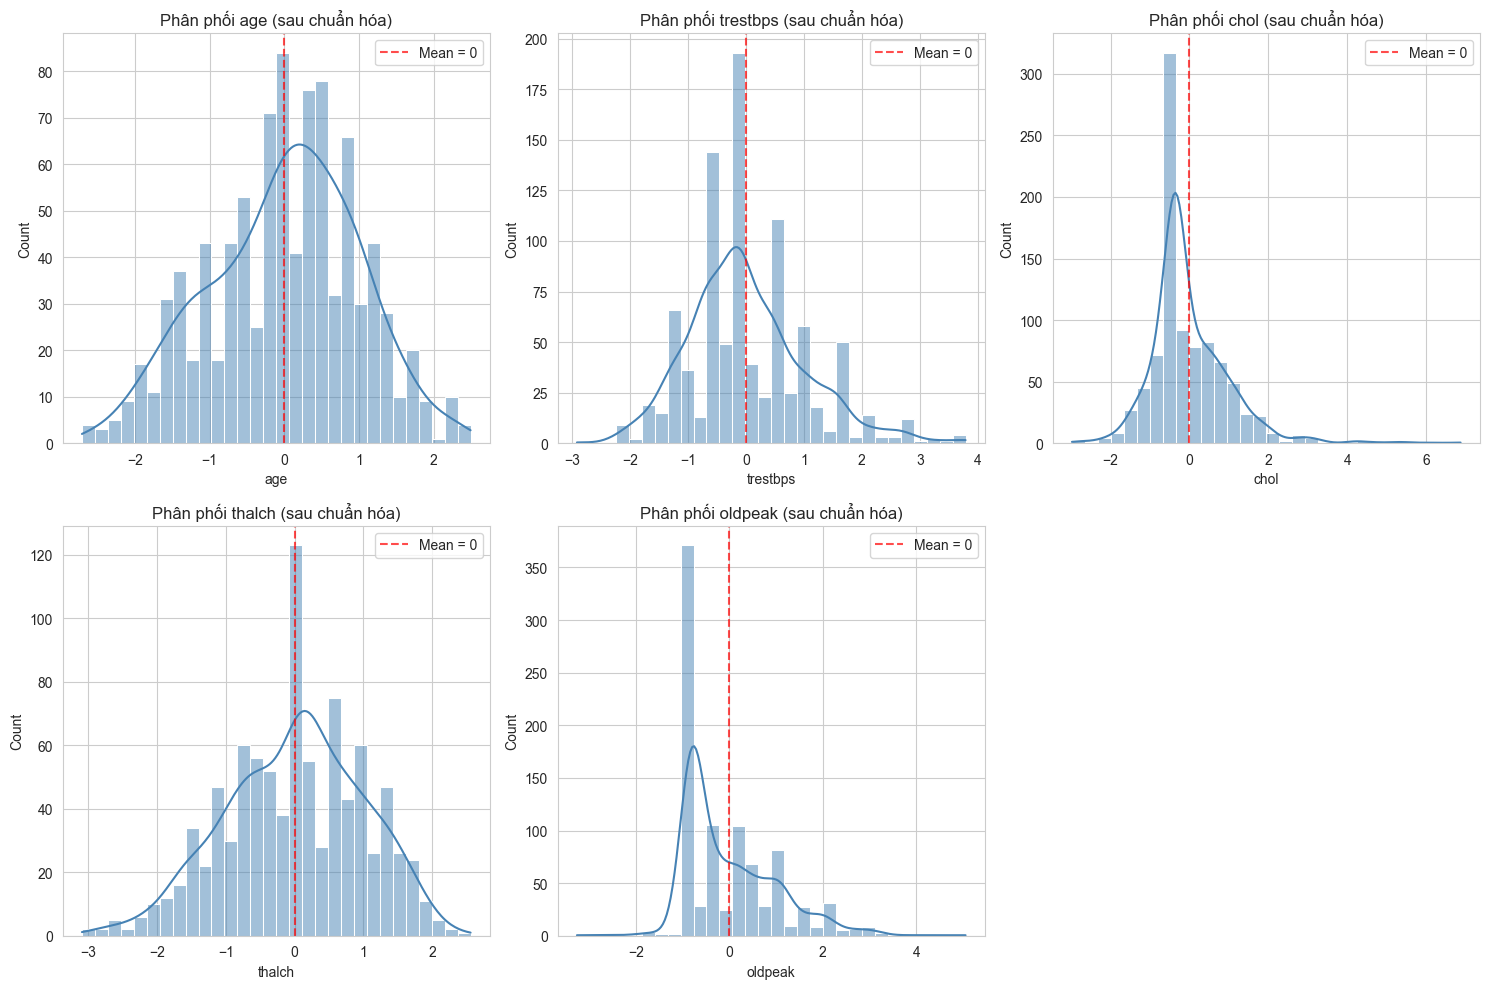

In [22]:

numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Phân phối {col} (sau chuẩn hóa)', fontsize=12)
    axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Mean = 0')
    axes[i].legend()

# Ẩn subplot thừa
axes[5].axis('off')
plt.tight_layout()
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/sau_khi_chuan_hoa.png")
plt.show()

3. BIỂU ĐỒ BOXPLOT SO SÁNH GIỮA HAI NHÓM


C:\Users\khanh\AppData\Local\Temp\ipykernel_12916\2519745782.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=data, ax=axes[i], palette=['#ff9999', '#66b3ff'])
C:\Users\khanh\AppData\Local\Temp\ipykernel_12916\2519745782.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=data, ax=axes[i], palette=['#ff9999', '#66b3ff'])
C:\Users\khanh\AppData\Local\Temp\ipykernel_12916\2519745782.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=data, ax=axes[i], palette=['#ff9999'

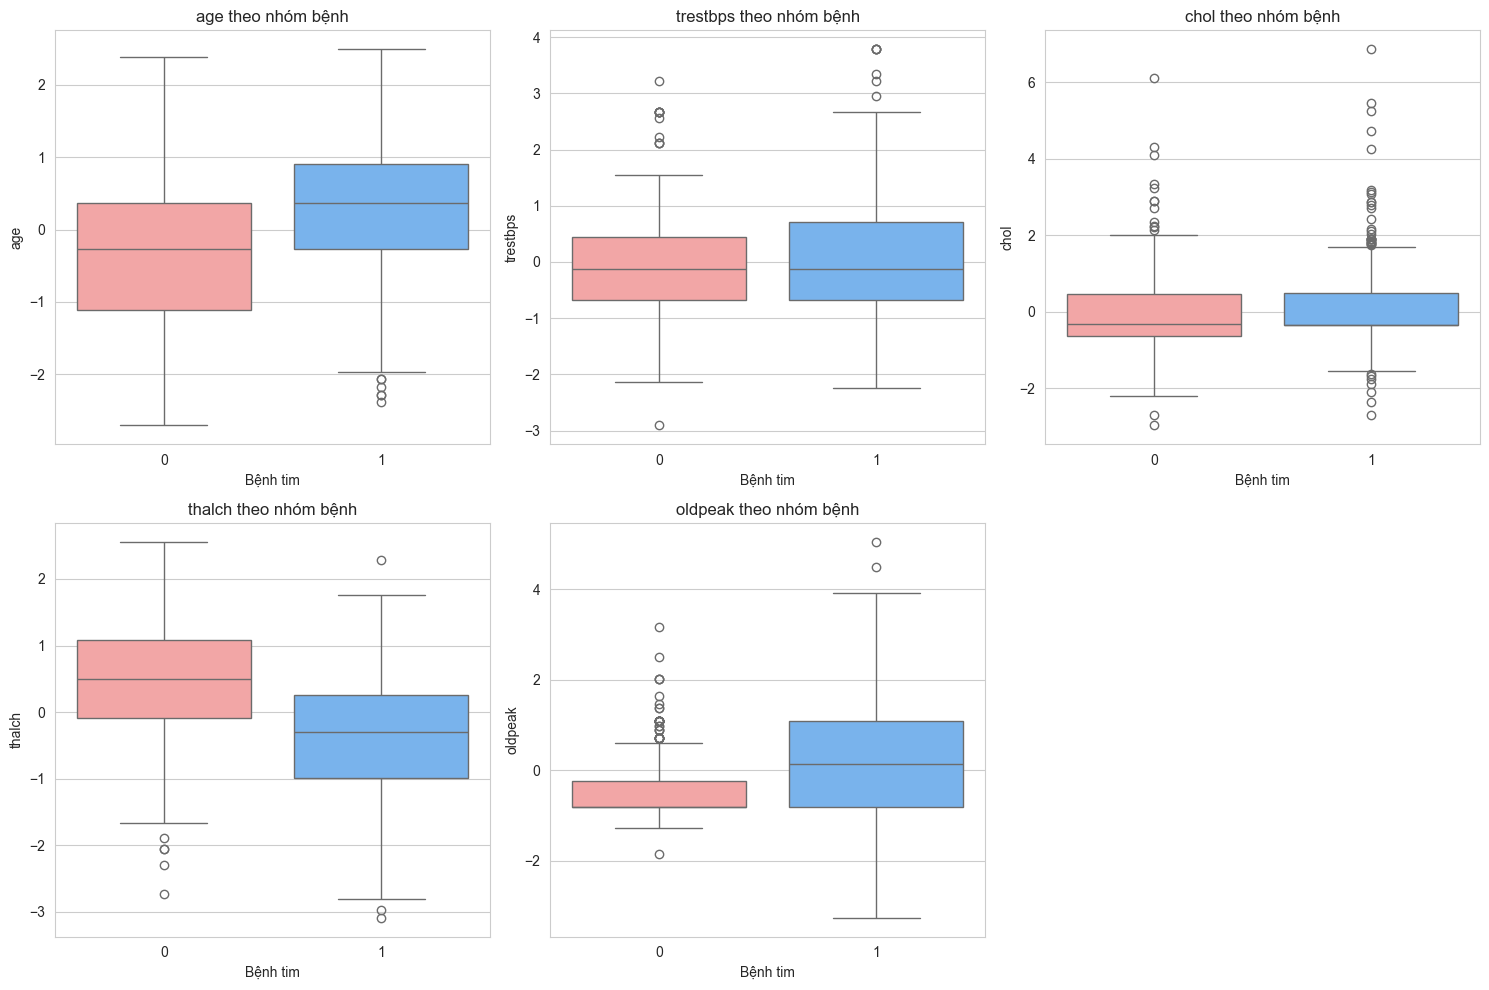

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='target', y=col, data=data, ax=axes[i], palette=['#ff9999', '#66b3ff'])
    axes[i].set_title(f'{col} theo nhóm bệnh', fontsize=12)
    axes[i].set_xlabel('Bệnh tim')
    axes[i].set_ylabel(col)

axes[5].axis('off')
plt.tight_layout()
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/so sanh theo nhom benh.png")
plt.show()

4. MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX)


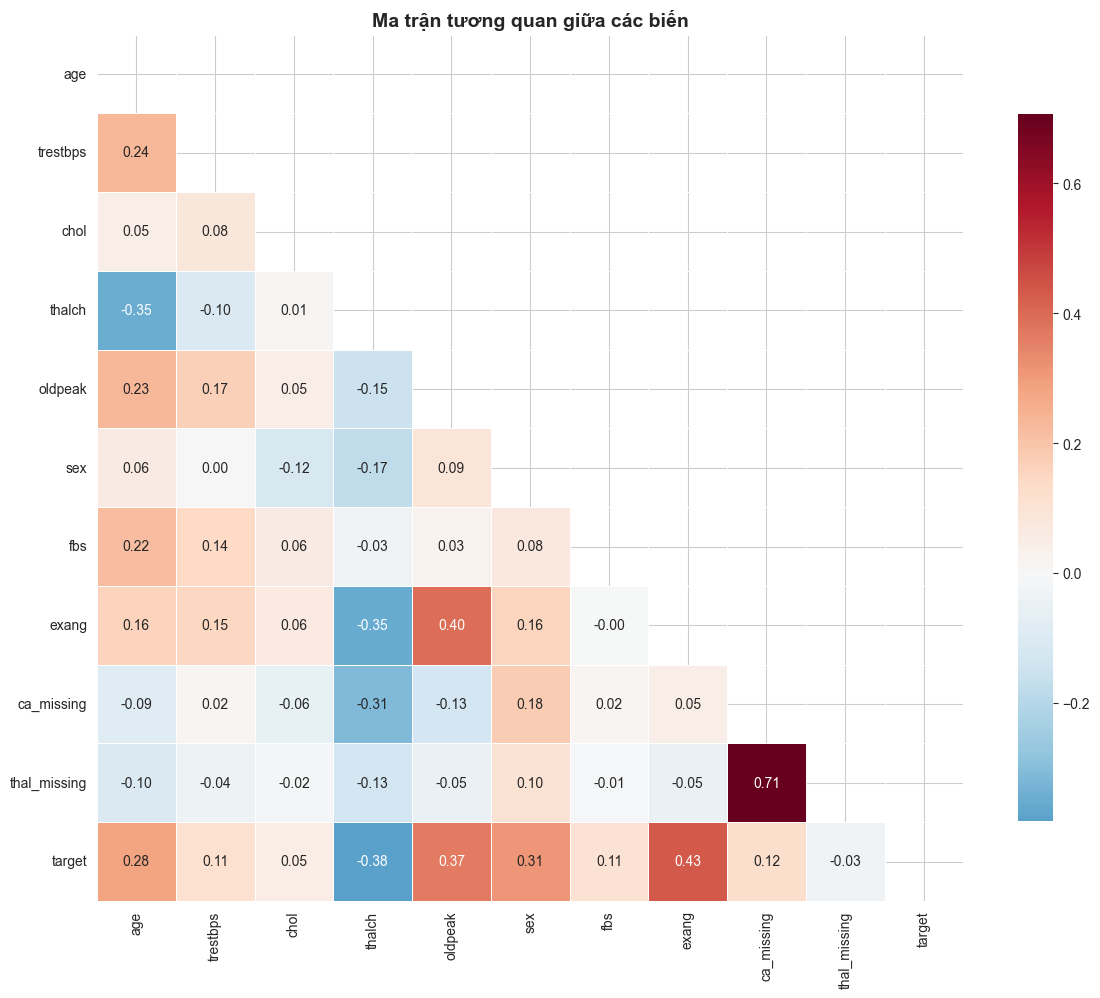

In [24]:
# Chọn các cột số để tính tương quan

corr_cols = numeric_cols + ['sex', 'fbs', 'exang', 'ca_missing', 'thal_missing', 'target']
corr_matrix = data[corr_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các biến', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/ma_tran_tuong_quan.png")
plt.show()

5. BIỂU ĐỒ VIOLIN CHO CÁC BIẾN SỐ CHÍNH


C:\Users\khanh\AppData\Local\Temp\ipykernel_12916\1289366857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='age', data=data, ax=axes[0], palette=['#ff9999', '#66b3ff'])
C:\Users\khanh\AppData\Local\Temp\ipykernel_12916\1289366857.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='chol', data=data, ax=axes[1], palette=['#ff9999', '#66b3ff'])
C:\Users\khanh\AppData\Local\Temp\ipykernel_12916\1289366857.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='thalch', data=data, ax=axes[2]

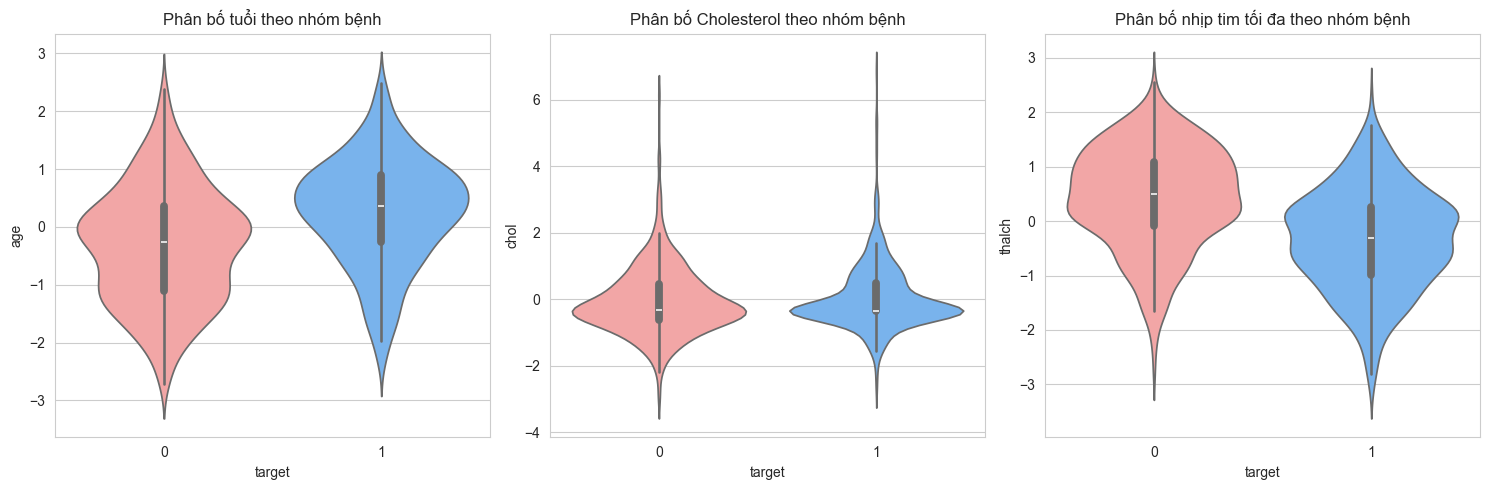

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age theo target
sns.violinplot(x='target', y='age', data=data, ax=axes[0], palette=['#ff9999', '#66b3ff'])
axes[0].set_title('Phân bố tuổi theo nhóm bệnh', fontsize=12)

# Cholesterol theo target
sns.violinplot(x='target', y='chol', data=data, ax=axes[1], palette=['#ff9999', '#66b3ff'])
axes[1].set_title('Phân bố Cholesterol theo nhóm bệnh', fontsize=12)

# Nhịp tim tối đa theo target
sns.violinplot(x='target', y='thalch', data=data, ax=axes[2], palette=['#ff9999', '#66b3ff'])
axes[2].set_title('Phân bố nhịp tim tối đa theo nhóm bệnh', fontsize=12)

plt.tight_layout()
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/violin_plots cho các biến số chính.png")
plt.show()

6. PHÂN TÍCH THEO GIỚI TÍNH


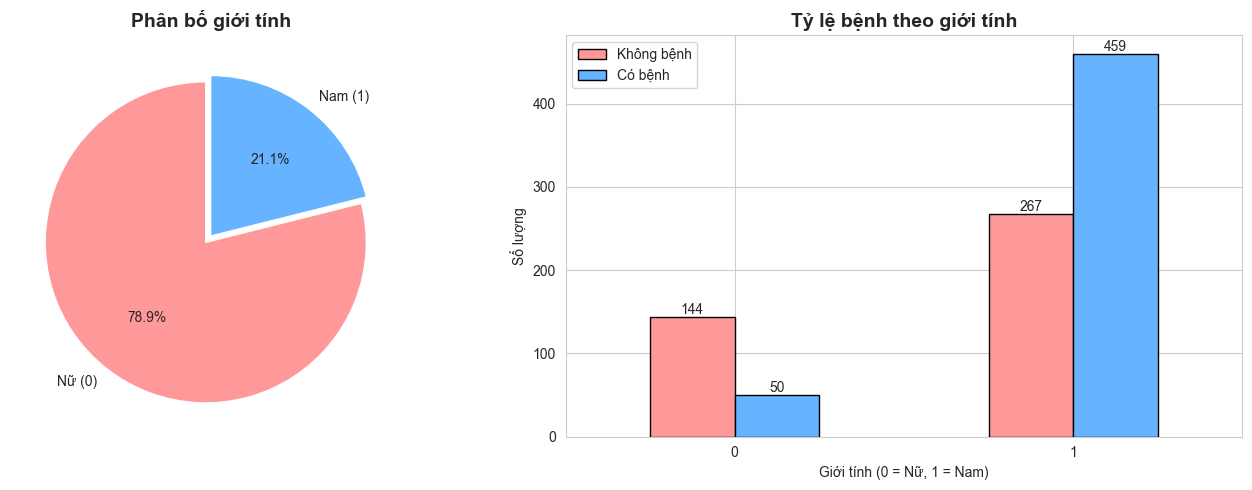

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân bố giới tính
sex_counts = data['sex'].value_counts()
axes[0].pie(sex_counts.values, labels=['Nữ (0)', 'Nam (1)'], autopct='%1.1f%%', 
            colors=['#ff9999', '#66b3ff'], startangle=90, explode=(0.05, 0))
axes[0].set_title('Phân bố giới tính', fontsize=14, fontweight='bold')

# Tỷ lệ bệnh theo giới tính
sex_disease = pd.crosstab(data['sex'], data['target'])
sex_disease.plot(kind='bar', ax=axes[1], color=['#ff9999', '#66b3ff'], edgecolor='black')
axes[1].set_title('Tỷ lệ bệnh theo giới tính', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Giới tính (0 = Nữ, 1 = Nam)')
axes[1].set_ylabel('Số lượng')
axes[1].legend(['Không bệnh', 'Có bệnh'])
axes[1].tick_params(axis='x', rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=10)

plt.tight_layout()
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/theo_gioi_tinh.png")
plt.show()

7. PHÂN TÍCH MỐI QUAN HỆ GIỮA CÁC BIẾN (PAIRPLOT)


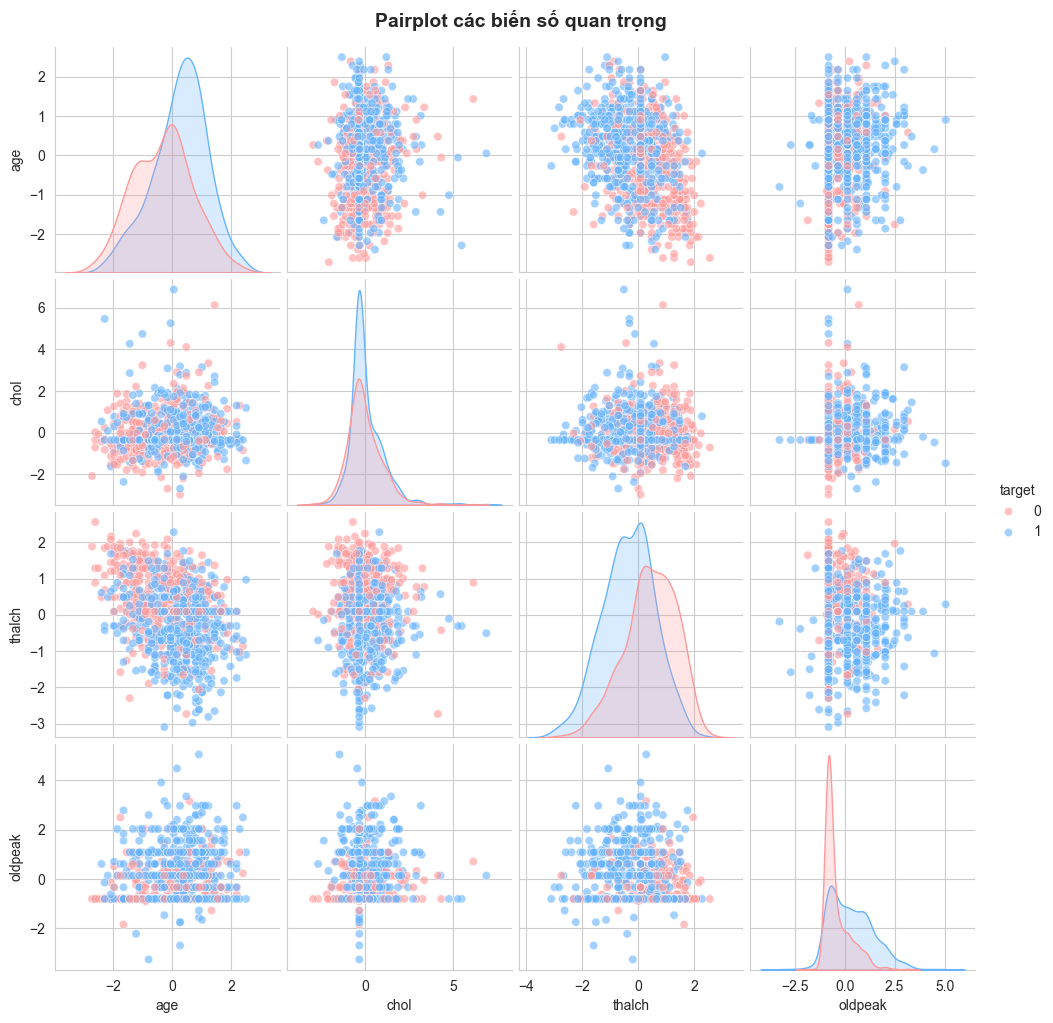

In [27]:
# Chọn một số biến quan trọng để vẽ pairplot
selected_cols = ['age', 'chol', 'thalch', 'oldpeak', 'target']
sns.pairplot(data[selected_cols], hue='target', diag_kind='kde', 
             palette=['#ff9999', '#66b3ff'], plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot các biến số quan trọng', y=1.02, fontsize=14, fontweight='bold')
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/mối quan hệ giữa các biến.png")
plt.show()

8. BIỂU ĐỒ PHÂN TÍCH CỘT ĐÃ XÓA (FLAG MISSING)

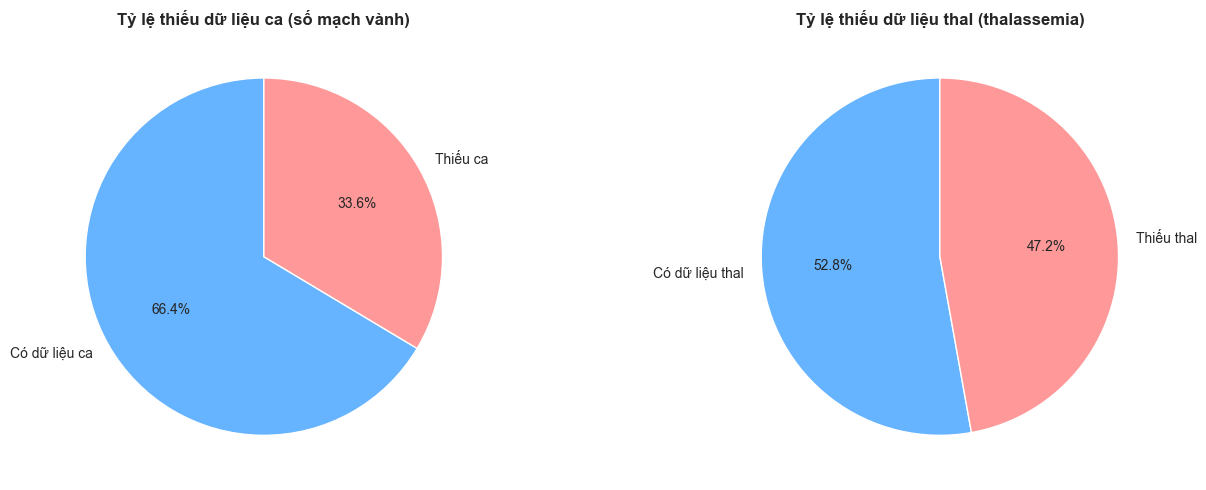

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân tích ca_missing
ca_missing_counts = data['ca_missing'].value_counts()
axes[0].pie(ca_missing_counts.values, labels=['Có dữ liệu ca', 'Thiếu ca'], 
            autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0].set_title('Tỷ lệ thiếu dữ liệu ca (số mạch vành)', fontsize=12, fontweight='bold')

# Phân tích thal_missing
thal_missing_counts = data['thal_missing'].value_counts()
axes[1].pie(thal_missing_counts.values, labels=['Có dữ liệu thal', 'Thiếu thal'], 
            autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
axes[1].set_title('Tỷ lệ thiếu dữ liệu thal (thalassemia)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/phân tích các cột đã xử lý( flag missing).png")
plt.show()

9. BIỂU ĐỒ TỔNG HỢP THỐNG KÊ MÔ TẢ

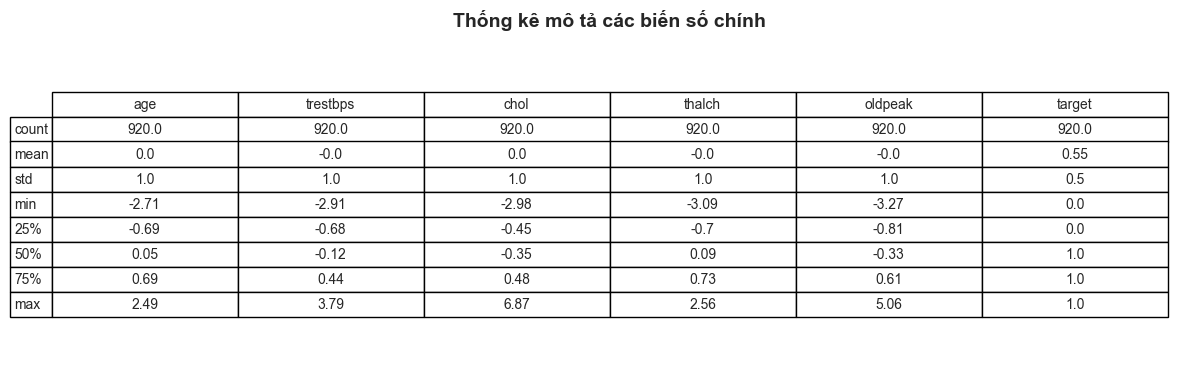

In [29]:
# Thống kê mô tả các biến số chính
desc_stats = data[numeric_cols + ['target']].describe().round(2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=desc_stats.values,
                 rowLabels=desc_stats.index,
                 colLabels=desc_stats.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Thống kê mô tả các biến số chính', fontsize=14, fontweight='bold', y=1.05)
plt.savefig("E:/AI_du_doan_benh_tim_mach/visualize/thong_ke_mo_ta_cac_bien_so_chinh.png")
plt.show()

10. IN KẾT LUẬN TỔNG QUAN

In [30]:
print("="*60)
print("📊 KẾT LUẬN TỔNG QUAN DỮ LIỆU")
print("="*60)

print(f"\n1. Số lượng mẫu: {data.shape[0]}")
print(f"2. Số lượng đặc trưng: {data.shape[1]}")
print(f"3. Tỷ lệ bệnh nhân có bệnh tim: {data['target'].mean()*100:.1f}%")
print(f"4. Tỷ lệ bệnh nhân không bệnh: {(1-data['target'].mean())*100:.1f}%")

print(f"\n5. Giới tính:")
print(f"   - Nữ: {(data['sex']==0).sum()} ({(data['sex']==0).mean()*100:.1f}%)")
print(f"   - Nam: {(data['sex']==1).sum()} ({(data['sex']==1).mean()*100:.1f}%)")

print(f"\n6. Tỷ lệ bệnh theo giới tính:")
print(f"   - Nữ: {data[data['sex']==0]['target'].mean()*100:.1f}%")
print(f"   - Nam: {data[data['sex']==1]['target'].mean()*100:.1f}%")

print(f"\n7. Dữ liệu thiếu (đã xử lý):")
print(f"   - ca (số mạch vành): {(data['ca_missing']==1).sum()} mẫu thiếu (đã tạo flag)")
print(f"   - thal (thalassemia): {(data['thal_missing']==1).sum()} mẫu thiếu (đã tạo flag)")

print(f"\n8. Các cột sau khi xử lý: {data.columns.tolist()}")
print("="*60)

📊 KẾT LUẬN TỔNG QUAN DỮ LIỆU

1. Số lượng mẫu: 920
2. Số lượng đặc trưng: 22
3. Tỷ lệ bệnh nhân có bệnh tim: 55.3%
4. Tỷ lệ bệnh nhân không bệnh: 44.7%

5. Giới tính:
   - Nữ: 194 (21.1%)
   - Nam: 726 (78.9%)

6. Tỷ lệ bệnh theo giới tính:
   - Nữ: 25.8%
   - Nam: 63.2%

7. Dữ liệu thiếu (đã xử lý):
   - ca (số mạch vành): 611 mẫu thiếu (đã tạo flag)
   - thal (thalassemia): 486 mẫu thiếu (đã tạo flag)

8. Các cột sau khi xử lý: ['id', 'age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca_missing', 'thal_missing', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach', 'target']


In [31]:
#lưu csv	đã xử lý
output_path = "E:/AI_du_doan_benh_tim_mach/data/data_process/heart_disease_processed.csv"
data.to_csv(output_path, index=False)

Xử lý outlier

In [33]:
# IQR method để phát hiện outlier
Q1 = data['chol'].quantile(0.25)
Q3 = data['chol'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['chol'] < lower_bound) | (data['chol'] > upper_bound)]
#	In kết quả
print(f"Số lượng outliers trong cột 'chol': {outliers.shape[0]}")
print(outliers[['chol', 'target']])


Số lượng outliers trong cột 'chol': 47
         chol  target
7    2.136819       0
38   2.117808       1
48   3.334503       0
75   2.250884       0
93  -1.912491       0
113  1.889678       1
121  3.144394       1
152  6.129097       0
173  2.897253       0
181  3.182416       1
202 -2.197654       0
291  1.908689       0
300 -2.102600       1
303 -2.083589       0
361  2.212863       0
373  3.239449       0
417 -2.140622       0
431 -2.691936       0
434  4.304056       0
458  2.345939       0
459  1.946711       0
461  2.897253       0
473 -2.977099       0
475  2.003743       0
499 -2.368752       1
500  4.266034       1
528  5.463718       1
531  2.859232       1
539  2.155830       1
546  6.870521       1
561  1.889678       1
564  1.908689       1
566  3.087362       1
568  5.254598       1
576  2.783188       1
584  4.741306       1
590  1.889678       1
594  1.908689       1
595  2.878242       1
748 -2.691936       1
800  4.113948       0
802  2.707145       1
826  2.041765  

In [35]:
#tính tỉ lệ huyết áp/tuổi
data['bp_age_ratio'] = data['trestbps'] / (data['age']) 
print("Đã tạo feature bp_age_ratio (huyết áp/tuổi)")
print(data[['trestbps', 'age', 'bp_age_ratio']].head())

Đã tạo feature bp_age_ratio (huyết áp/tuổi)
   trestbps       age  bp_age_ratio
0  0.717803  1.007386      0.712541
1  1.554856  1.432034      1.085768
2 -0.677285  1.432034     -0.472953
3 -0.119250 -1.752828      0.068033
4 -0.119250 -1.328180      0.089784


In [42]:
# ============================================
# FEATURE ENGINEERING (TẠO ĐẶC TRƯNG MỚI)
# ============================================

# 1. Phân nhóm tuổi
data['age_group'] = pd.cut(data['age'], bins=[0, 40, 50, 60, 100], 
                            labels=['<40', '40-50', '50-60', '>60'])
data = pd.get_dummies(data, columns=['age_group'], prefix='age')

data['risk_score_binary'] = (
    ((data['age'] * 1) > 50).astype(int) +           # tuổi > 50
    (data['sex'] == 1).astype(int) +                  # nam giới
    (data['trestbps'] > 140).astype(int) +            # huyết áp > 140
    (data['chol'] > 240).astype(int) +                # cholesterol > 240
    (data['fbs'] == 1).astype(int) +                  # đường huyết cao
    (data['exang'] == 1).astype(int) +                # đau thắt ngực
    (data['oldpeak'] > 1.5).astype(int)               # ST chênh lệch > 1.5
)

print("Đã tạo feature mới")
print(f"Shape sau khi thêm feature: {data.shape}")
print(data[['age', 'sex', 'trestbps', 'chol', 'fbs', 'exang', 'oldpeak', 'risk_score']].head())

Đã tạo feature mới
Shape sau khi thêm feature: (920, 37)
        age  sex  trestbps      chol  fbs  exang   oldpeak  risk_score
0  1.007386    1  0.717803 -0.163493    1      0  1.368109           5
1  1.432034    1  1.554856  0.844082    0      1  0.611589           6
2  1.432034    1 -0.677285 -0.239537    0      1  1.651804           4
3 -1.752828    1 -0.119250  0.159691    0      0  2.502889           2
4 -1.328180    0 -0.119250 -0.714808    0      0  0.517024           1


In [47]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Chuẩn bị dữ liệu
X = data.drop(columns=['target', 'id'])  # bỏ target và id
y = data['target']

print("📊 Phân phối target trước xử lý:")
print(Counter(y))

# Áp dụng SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\n📊 Phân phối target sau SMOTE:")
print(Counter(y_resampled))
print(f"Shape trước: {X.shape}, Sau: {X_resampled.shape}")

📊 Phân phối target trước xử lý:
Counter({1: 509, 0: 411})

📊 Phân phối target sau SMOTE:
Counter({0: 509, 1: 509})
Shape trước: (920, 35), Sau: (1018, 35)


In [ ]:
#lưu lại vào csv sau khi tạo feature
output_path = "E:/AI_du_doan_benh_tim_mach/data/data_process/heart_disease_processed_on_train.csv"
data.to_csv(output_path, index=False)